# Section J: Exploratory Data Analysis (EDA)

In [31]:
import pandas as pd 

In [32]:
df = pd.read_csv(r"D:\data-science-journey\Data_Science\Data\Flight_Booking_Advanced_Dirty_Dataset_5500_Records.csv")

In [33]:
df.columns

Index(['BookingID', 'BookingDate', 'CustomerID', 'CustomerName', 'Gender',
       'Age', 'MobileNo', 'EmailID', 'City', 'Country', 'FlightID',
       'FlightName', 'FlightNumber', 'SourceCity', 'SourceAirport',
       'DestinationCity', 'DestinationAirport', 'FlightDate', 'DepartureTime',
       'ArrivalTime', 'SeatClass', 'SeatNumber', 'PNRNumber', 'TicketPrice',
       'TaxAmount', 'TotalAmount', 'PaymentMode', 'PaymentStatus',
       'BookingStatus'],
      dtype='object')

In [34]:
# Count total bookings.
df['BookingStatus'].value_counts() 

BookingStatus
Confirmed    1798
Waiting      1749
Cancelled    1729
Name: count, dtype: int64

In [35]:
# Count bookings by city. 
df.groupby('City').value_counts()

City         BookingID  BookingDate  CustomerID  CustomerName       Gender  Age      MobileNo      EmailID                  Country    FlightID  FlightName       FlightNumber  SourceCity  SourceAirport                                      DestinationCity  DestinationAirport                                 FlightDate  DepartureTime  ArrivalTime  SeatClass        SeatNumber  PNRNumber   TicketPrice  TaxAmount  TotalAmount  PaymentMode  PaymentStatus  BookingStatus
Adoni        222        2026-03-20   CUST000222  Omaja Srinivas     Male    40.0     9915823026.0  sundervidhi@example.org  India      FL000222  Emirates         AI4369        Singapore   Singapore Changi Airport                           Dubai            Dubai International Airport                        2026-05-24  07:15          10:15        First Class      2D          PNR5198227  63144        3157.20    66301.20     Credit Card  Paid           Confirmed        1
             1603       2026-06-16   CUST001603  Ekantika Mod

In [36]:
# Count bookings by country. 
df.groupby('Country').value_counts()

Country  BookingID  BookingDate  CustomerID  CustomerName    Gender  Age   MobileNo      EmailID                      City           FlightID  FlightName      FlightNumber  SourceCity  SourceAirport                                      DestinationCity  DestinationAirport                                FlightDate  DepartureTime  ArrivalTime  SeatClass        SeatNumber  PNRNumber   TicketPrice  TaxAmount  TotalAmount  PaymentMode  PaymentStatus  BookingStatus
India    43         2026-05-16   CUST000043                  Female  23.0  1321348771.0  yachanajani@example.com      Bareilly       FL000043  vistara123      6E3213        Mumbai      Chhatrapati Shivaji Maharaj International Airport  Jaipur           Jaipur International Airport                      2026-07-01  16:45          18:45        Economy          5D          PNR8524534   28184       1409.20    29593.20     Net Banking  Pending        Waiting          2
         123        2026-03-03   CUST000123                  Male    

In [37]:
# Count bookings by airline
df.groupby('FlightNumber').value_counts()

FlightNumber  BookingID  BookingDate  CustomerID  CustomerName            Gender  Age   MobileNo      EmailID                     City         Country  FlightID  FlightName          SourceCity  SourceAirport                                     DestinationCity  DestinationAirport                                FlightDate  DepartureTime  ArrivalTime  SeatClass        SeatNumber  PNRNumber   TicketPrice  TaxAmount  TotalAmount  PaymentMode  PaymentStatus  BookingStatus
6E1003        1946       2025-12-15   CUST001946  Isaiah Shanker          Male    25.0  6036218989.0  hyohannan@example.org       Guntur       UK       FL001946  Singapore Airlines  Hyderabad   Rajiv Gandhi International Airport                Delhi            Indira Gandhi International Airport               2026-03-18  13:45          18:45        Premium Economy  50C         PNR5787988  19962        998.10     20960.10     Net Banking  Paid           Waiting          1
6E1035        4369       2025-10-25   CUST004369  Abh

In [38]:
# Find top 10 airlines. 
df['FlightName'].value_counts().nlargest(10)

FlightName
Thai Airways          474
Emirates              452
SpiceJet              447
Akasa Air             447
Singapore Airlines    445
Vistara               442
IndiGo                428
Qatar Airways         425
Etihad Airways        425
British Airways       412
Name: count, dtype: int64

In [39]:
# Find top 10 cities. 
df['City'].value_counts().nlargest(10)


City
Ghaziabad               39
Aurangabad              29
Buxar                   27
Hajipur                 27
Shivpuri                26
Munger                  26
Kirari Suleman Nagar    26
New Delhi               26
Jorhat                  26
Kakinada                25
Name: count, dtype: int64

In [40]:
# Calculate average ticket price.
# 328. Calculate median ticket price.
# 329. Calculate total revenue. 

df['TicketPrice'].mean()
df['TicketPrice'].median()
df['TicketPrice'].sum()

np.int64(205822382)

In [41]:
df['FlightDate'] = pd.to_datetime(
    df['FlightDate'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

monthly_revenue = df.groupby(df['FlightDate'].dt.to_period('M'))['TotalAmount'].sum()

print(monthly_revenue)

FlightDate
2025-07     3235455.30
2025-08     7376694.15
2025-09    11136534.15
2025-10    16033949.40
2025-11    15911685.30
2025-12    16266559.05
2026-01    16817356.50
2026-02    14632542.75
2026-03    16715389.95
2026-04    14840290.50
2026-05    17620399.65
2026-06    17275942.95
2026-07    13534379.25
2026-08     9758236.95
2026-09     4597514.25
2026-10     1001647.50
Freq: M, Name: TotalAmount, dtype: float64


In [42]:
df.groupby(df['FlightDate'].dt.to_period('Y'))['TotalAmount'].sum()


FlightDate
2025    6.996088e+07
2026    1.267937e+08
Freq: Y-DEC, Name: TotalAmount, dtype: float64

In [46]:
# Calculate bookings per month. 
df.groupby(df['BookingDate'].dt.to_period('M')).size()



BookingDate
2025-06    116
2025-07    474
2025-08    459
2025-09    483
2025-10    428
2025-11    438
2025-12    463
2026-01    468
2026-02    409
2026-03    457
2026-04    434
2026-05    499
2026-06    372
Freq: M, dtype: int64

In [49]:
# Calculate bookings by SeatClass. 
df.groupby('BookingDate')['SeatClass'].size()

BookingDate
2025-06-23    17
2025-06-24    12
2025-06-25    16
2025-06-26    11
2025-06-27    11
              ..
2026-06-18    14
2026-06-19    20
2026-06-20    15
2026-06-21    16
2026-06-22    23
Name: SeatClass, Length: 365, dtype: int64

In [51]:
# Calculate bookings by PaymentStatus. 
df.groupby('BookingDate')['PaymentStatus'].value_counts()

BookingDate  PaymentStatus
2025-06-23   Paid              6
             Pending           6
             Refunded          3
2025-06-24   Pending           5
             Refunded          4
                              ..
2026-06-21   Paid              8
             Pending           3
2026-06-22   Pending          10
             Refunded          8
             Paid              5
Name: count, Length: 1076, dtype: int64

In [52]:
# Calculate bookings by BookingStatus. 
df.groupby('BookingDate')['BookingStatus'].value_counts()

BookingDate  BookingStatus
2025-06-23   Confirmed        7
             Waiting          6
             Cancelled        4
2025-06-24   Waiting          5
             Cancelled        4
                             ..
2026-06-21   Waiting          4
             Confirmed        3
2026-06-22   Confirmed        8
             Cancelled        7
             Waiting          5
Name: count, Length: 1083, dtype: int64

In [53]:
# Calculate gender distribution.
df['Gender'].value_counts()

Gender
Female    2822
Male      2678
Name: count, dtype: int64

In [55]:
# Calculate age distribution.
df['Age'].value_counts()

Age
34.0        104
65.0        101
35.0         98
49.0         98
40.0         93
           ... 
63.0         58
-5           56
250          54
18 Years     47
Twenty       44
Name: count, Length: 63, dtype: int64

In [58]:
# Calculate average age. 
df['Age'] = pd.to_numeric(df['Age'], errors='coerce').mean()

df['Age'].mean()

np.float64(47.778967254408045)

In [59]:
# Calculate variance of TicketPrice.
df['TicketPrice'].var()

np.float64(520355996.40166235)

In [67]:
# Find highest revenue flight.
df.groupby('FlightName')['TotalAmount'].sum().nlargest().head(1)

FlightName
Thai Airways    19944026.55
Name: TotalAmount, dtype: float64

In [68]:
# Find lowest revenue flight. 
df.groupby('FlightName')['TotalAmount'].sum().nsmallest().head(1)

FlightName
INDIGO     1842612.45
Name: TotalAmount, dtype: float64

In [69]:
# Find most preferred SeatClass.
df.groupby('SeatClass')['Age'].sum().nsmallest().head(1)

SeatClass
Business    56713.634131
Name: Age, dtype: float64

In [76]:
# Find most preferred airline. 
df.groupby('FlightName').size().nlargest().head(1)

FlightName
Thai Airways    474
dtype: int64

In [78]:
# Find most common route. 
df.groupby('DestinationCity').size().nlargest().head(1)

DestinationCity
Doha    363
dtype: int64

In [79]:
df.groupby('DestinationCity').size().nsmallest().head(1)

DestinationCity
Ahmedabad    308
dtype: int64

In [83]:
# Generate descriptive statistics
df.describe()
print(df.describe(include='all'))

          BookingID                    BookingDate  CustomerID CustomerName  \
count   5500.000000                           5500        5500         4566   
unique          NaN                            NaN        5000         4464   
top             NaN                            NaN  CUST000801                
freq            NaN                            NaN           2           66   
mean    2501.542364  2025-12-23 10:32:33.163636224         NaN          NaN   
min        1.000000            2025-06-23 00:00:00         NaN          NaN   
25%     1253.750000            2025-09-20 00:00:00         NaN          NaN   
50%     2512.500000            2025-12-23 12:00:00         NaN          NaN   
75%     3751.000000            2026-03-27 00:00:00         NaN          NaN   
max     5000.000000            2026-06-22 00:00:00         NaN          NaN   
std     1445.917827                            NaN         NaN          NaN   

        Gender           Age    MobileNo        Ema

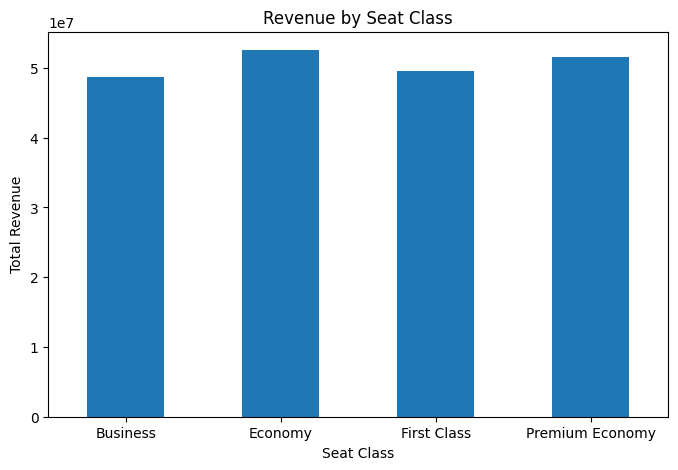

In [86]:
# Create Dashboard
import matplotlib.pyplot as plt

# Revenue by Seat Class
revenue = df.groupby('SeatClass')['TotalAmount'].sum()

plt.figure(figsize=(8, 5))
revenue.plot(kind='bar')
plt.title('Revenue by Seat Class')
plt.xlabel('Seat Class')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Section K: Data Visualization using Matplotlib